In [25]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, random_split, DataLoader, dataset

# import torch.nn.functional as F
# import pathlib

# from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# import os
import numpy as np

import pathlib

# from PIL import Image
# import xml.etree.ElementTree as ET




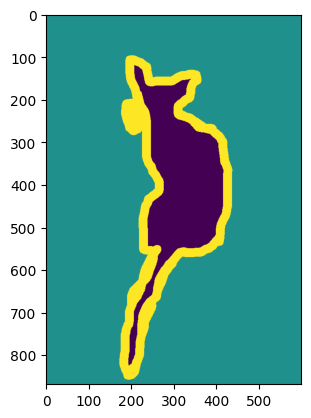

In [35]:
from PIL import Image
arr = Image.open("oxford-iiit-pet/annotations/trimaps/Abyssinian_3.png")
plt.imshow(np.array(arr))

In [2]:
BATCH_SIZE = 50
train_ratio = 0.8

In [3]:
from data.pets_dataset import OxfordIIITPetDataset, get_class_map
from losses import IoULoss

from models import VGG11Classifier, VGG11Localizer, VGG11Encoder, VGG11UNet

In [4]:
dataset = OxfordIIITPetDataset(root_dir = "oxford-iiit-pet")

train_ds, test_ds = random_split(dataset, [int(train_ratio * len(dataset)), len(dataset)-int(train_ratio * len(dataset))])

train_dl = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size = BATCH_SIZE, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# classifier
model_classifier = VGG11Classifier(num_classes=37, in_channels=3)
checkpoint = torch.load("classifier.pth", map_location=device)
model_classifier.load_state_dict(checkpoint['state_dict'])
model_classifier.to(device)
model_classifier.eval()

# localizer
model_localizer = VGG11Localizer(copy.deepcopy(model_classifier.conv_layers))
checkpoint = torch.load("localizer.pth", map_location=device)
model_localizer.load_state_dict(checkpoint['state_dict'])
model_localizer.to(device)
model_localizer.eval()

# unet
unet = VGG11UNet(num_classes = 1)
checkpoint = torch.load("unet.pth", map_location=device)
unet.load_state_dict(checkpoint['state_dict'])
unet.to(device)
unet.eval()

print("imported and loaded")

imported and loaded


In [6]:
mappings = get_class_map(pathlib.Path("oxford-iiit-pet"))

Actual:    pomeranian
Predicted: pomeranian
0.71049935 0.25754166 0.43760318 0.50311774


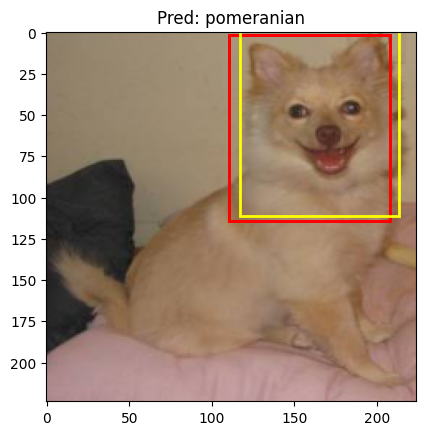

In [56]:
idx = 0
model_classifier.eval()
sample = next(iter(train_dl))
sample_image = sample['image'][idx]
sample_bbox = sample['bbox'][idx]
sample_class_id = sample['class_id'][idx]

sample_pred_logits = model_classifier(sample_image.unsqueeze(0))
sample_preds = torch.softmax(sample_pred_logits, dim = 1)
sample_class_id_pred = torch.argmax(sample_preds)

print(f"Actual:    {mappings[sample_class_id.item()]}")
print(f"Predicted: {mappings[sample_class_id_pred.item()]}")

sample_bbox_pred = model_localizer(sample_image.unsqueeze(0))
sample_numpy_image = sample_image.permute(1,2,0).detach().cpu().numpy()

mean = torch.tensor([0.485, 0.456, 0.406], device=sample_image.device).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225], device=sample_image.device).view(3, 1, 1)
sample_image = sample_image * std + mean
sample_numpy_image = sample_image.permute(1,2,0).detach().cpu().numpy()

H, W, _ = sample_numpy_image.shape

x, y, w, h = sample_bbox_pred.squeeze().detach().cpu().numpy()
print(x, y, w, h)

# normalized -> pixel
x = x * W
y = y * H
w = w * W
h = h * H

# center -> top-left
x = x - w/2
y = y - h/2

fig, ax = plt.subplots(1)

ax.imshow(sample_numpy_image)

# Predicted bbox (RED)
rect_pred = patches.Rectangle(
    (x, y), w, h,
    linewidth=2, edgecolor='r', facecolor='none'
)
ax.add_patch(rect_pred)


# Predicted bbox (RED)
rect_pred = patches.Rectangle(
    (x, y), w, h,
    linewidth=2, edgecolor='r', facecolor='none'
)
ax.add_patch(rect_pred)

# actual bbox (YELLOW)
xc, yc, w_gt, h_gt = sample_bbox.cpu().numpy()

x_gt = xc * W
y_gt = yc * H
w_gt = w_gt * W
h_gt = h_gt * H

# center -> top-left
x_gt = x_gt - w_gt/2
y_gt = y_gt - h_gt/2

rect_gt = patches.Rectangle(
    (x_gt, y_gt), w_gt, h_gt,
    linewidth=2, edgecolor='Yellow', facecolor='none'
)

ax.add_patch(rect_gt)

plt.title(f"Pred: {mappings[sample_class_id_pred.item()]}")
plt.show()


In [7]:
encoder = VGG11Encoder()

def copy_weights(old_seq, new_blocks):
    old_layers = list(old_seq.children())

    idx = 0
    for block in new_blocks:
        for layer in block:
            if isinstance(layer, (nn.Conv2d, nn.BatchNorm2d)):
                layer.weight.data = old_layers[idx].weight.data.clone()
                layer.bias.data   = old_layers[idx].bias.data.clone()
                idx += 1
            elif isinstance(layer, nn.ReLU):
                idx += 1  # skip ReLU
        idx += 1  # skip MaxPool


copy_weights(model_classifier.conv_layers, [
    encoder.block1,
    encoder.block2,
    encoder.block3,
    encoder.block4,
    encoder.block5
])

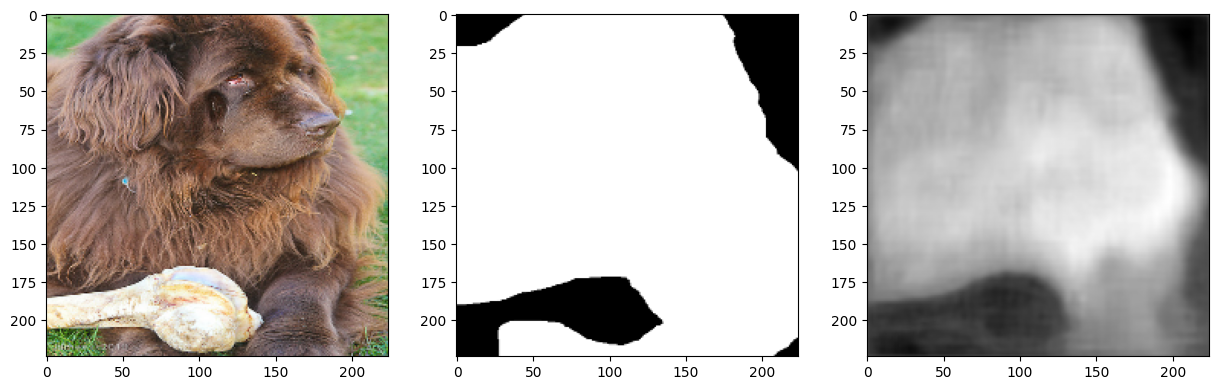

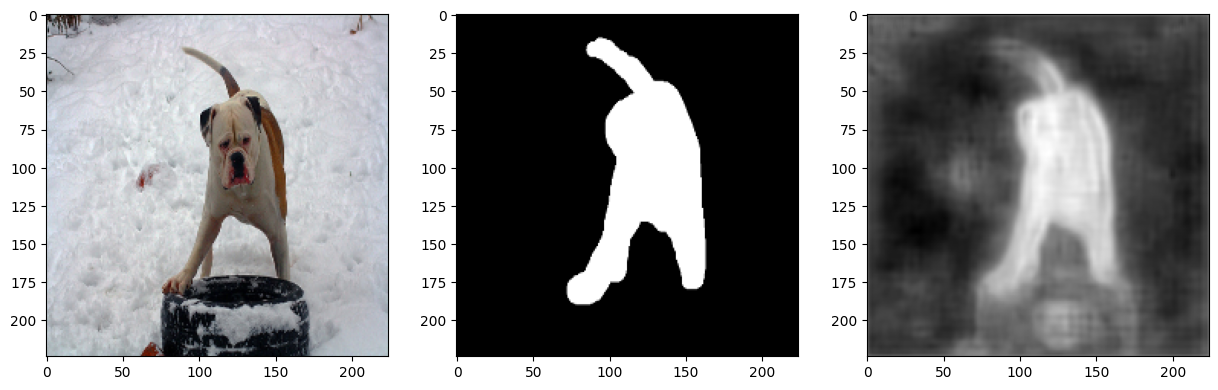

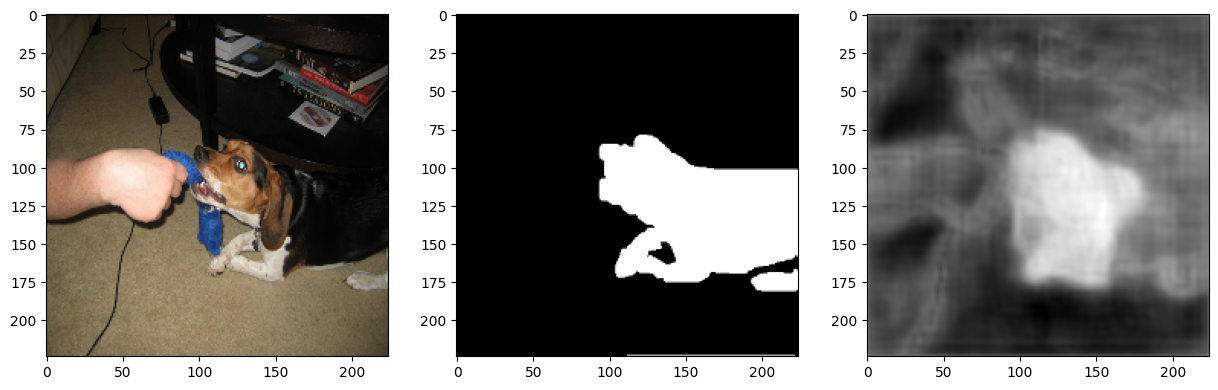

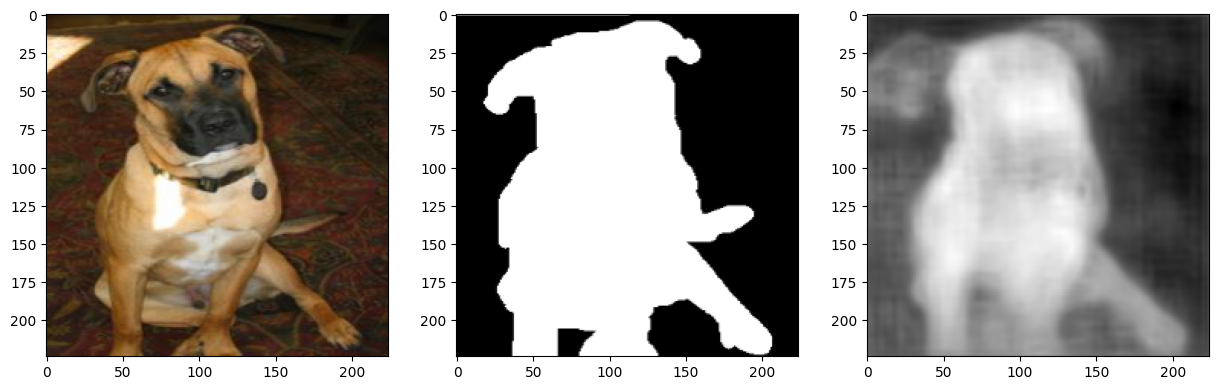

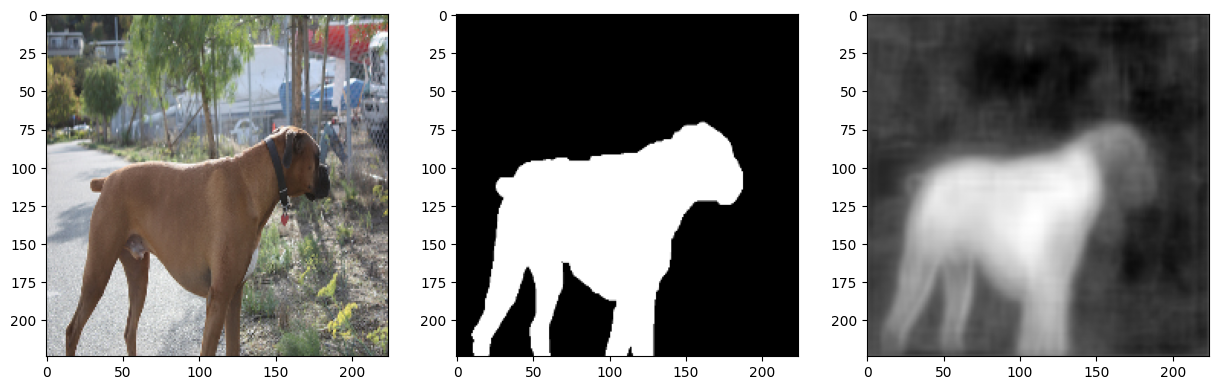

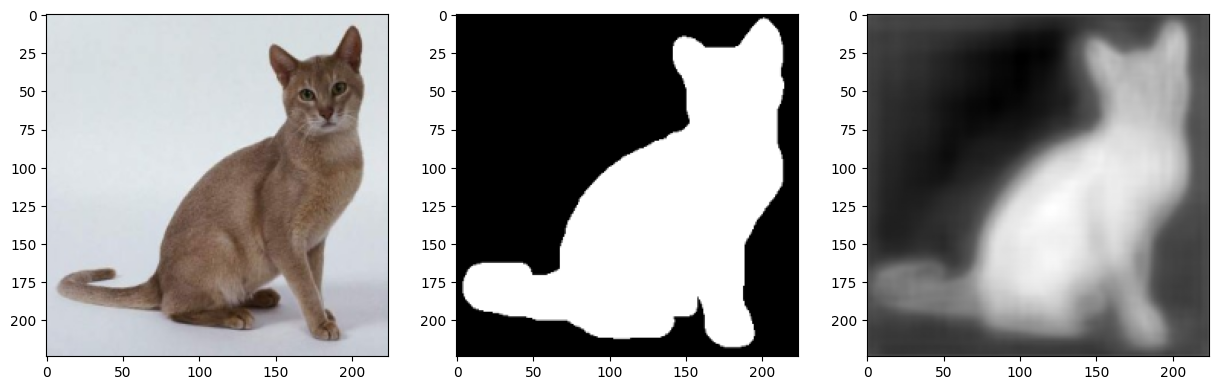

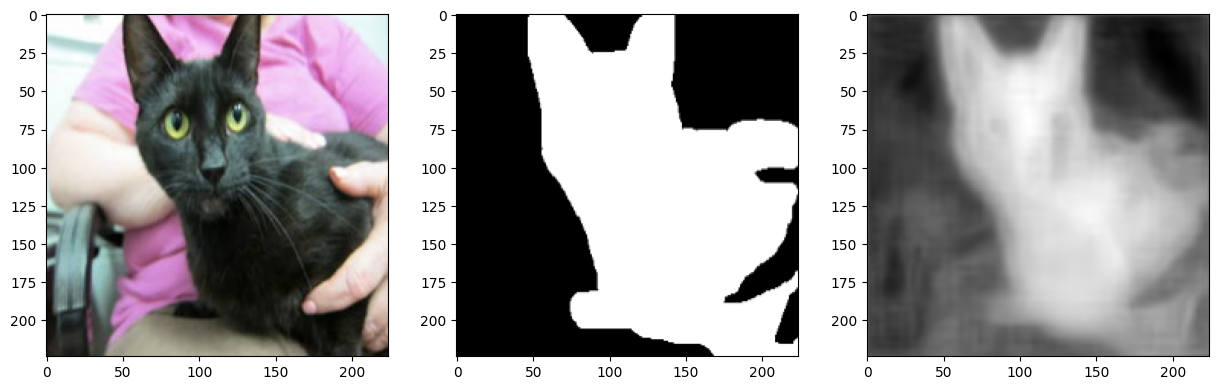

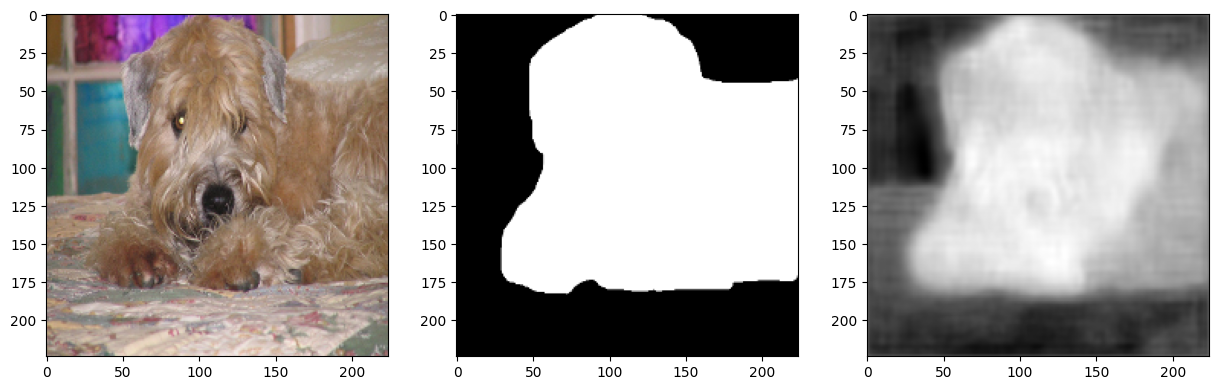

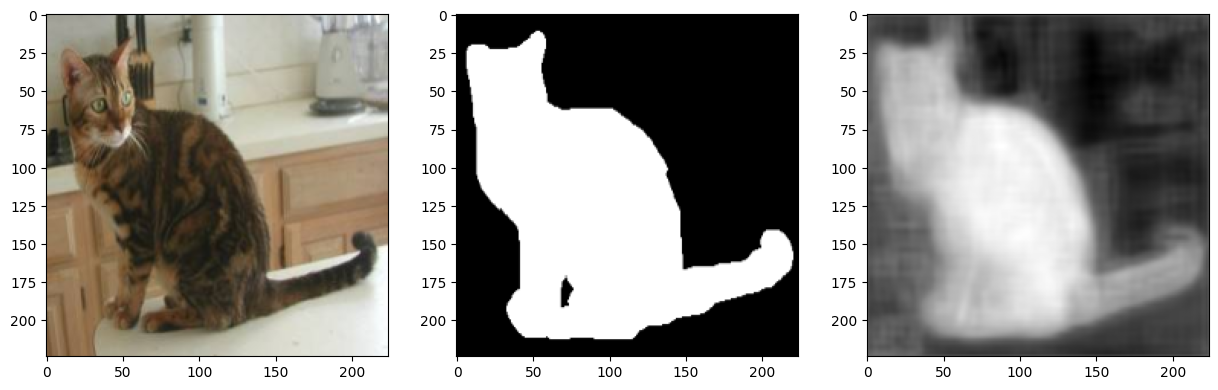

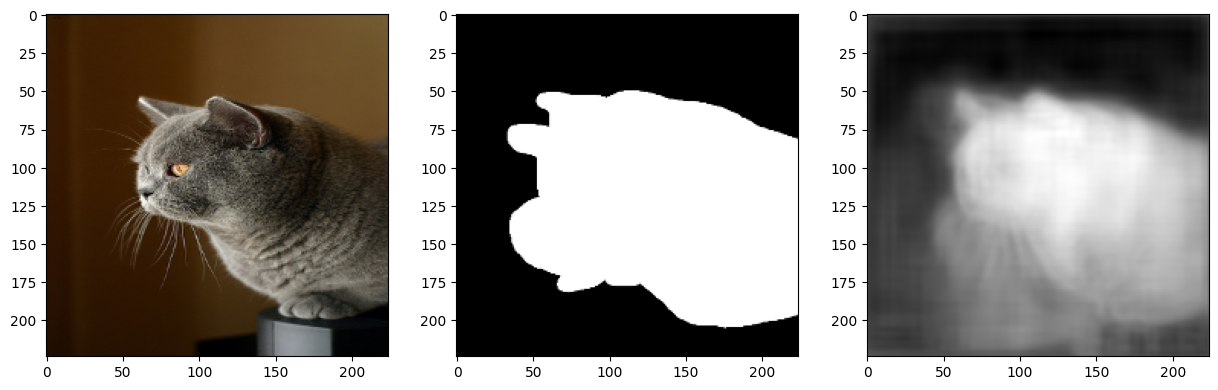

In [8]:
for i in range(10):
    sample = next(iter(train_dl))
    sample_image = sample["image"]
    sample_mask = sample["mask"]

    sample_image_one = sample_image[0].unsqueeze(0)
    sample_mask_one_pred = unet(sample_image_one)[0].permute(1,2,0).detach().cpu().numpy()

    sample_mask_one = sample_mask[0]

    mean = torch.tensor([0.485, 0.456, 0.406], device=sample_image.device).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=sample_image.device).view(3, 1, 1)
    sample_image_one = (sample_image_one * std + mean)[0]
    sample_numpy_image = sample_image_one.permute(1,2,0).detach().cpu().numpy()
    sample_numpy_mask = sample_mask_one.permute(1,2,0).detach().cpu().numpy()


    plt.figure(figsize=(15,15))
    plt.subplot(1,3,1)
    plt.imshow(sample_numpy_image)
    plt.subplot(1,3,2)
    plt.imshow(sample_numpy_mask, cmap="gray")
    plt.subplot(1,3,3)
    plt.imshow(sample_mask_one_pred, cmap="gray")
    plt.show()